<div align="center">
    
# Mortgage Risk Modeling
# 6.0 Prepayment Risk Modeling

## 6.1 Table of Contents<a id='6.1_Table_of_Contents'></a>

- [6.2 Introduction](#6.2_Introduction)
- [6.3 Library Imports](#6.3_Library_Imports)
- [6.4 Data Loading](#6.4_Data_Loading)
- [6.5 Data Transformation](#6.5_Data_Transformation)
- [6.6 Model Development and Evaluation](#6.6_Model_Development_and_Evaluation)
  - [6.6.1 Model Training](#6.6.1_Model_Training)
  - [6.6.2 Model Evaluation](#6.6.2_Model_Evaluation)
  - [6.6.3 Threshold Tuning](#6.6.3_Threshold_Tuning)
  - [6.6.4 Model Selection](#6.6.4_Model_Selection)
- [6.7 Summary](#6.7_Summary)

## 6.2 Introduction<a id='6.2_Introduction'></a>

This notebook focuses on developing a prepayment risk model using the processed outputs from the feature engineering stage. The raw train-test splits and the fitted feature transformer from the previous notebook are reused here to ensure consistency across the modeling pipeline.

Unlike the default target, the prepayment target is relatively balanced. Therefore, no resampling step is applied in this notebook. The transformed training and test datasets are used directly for model development and evaluation.

Model performance is assessed using **Accuracy, F1-score, and AUC-ROC**. Several classification models are trained and compared, followed by threshold tuning for the strongest candidate. The notebook concludes by selecting the final prepayment model and interpreting its performance through the confusion matrix.

## 6.3 Library Imports<a id='6.3_Library_Imports'></a>

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

RANDOM_STATE = 17
np.random.seed(RANDOM_STATE)

## 6.4 Data Loading<a id='6.4_Data_Loading'></a>

In [2]:
# Load raw split data
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)
y_train = pd.read_csv('../data/processed/y_prepaid_train.csv', index_col=0).squeeze()
y_test = pd.read_csv('../data/processed/y_prepaid_test.csv', index_col=0).squeeze()

# Load fitted transformer
transformer = joblib.load('../models/feature_transformer.pkl')

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(83896, 22)
(20975, 22)
(83896,)
(20975,)


## 6.5 Data Transformation<a id='6.5_Data_Transformation'></a>

The raw training and test datasets loaded from the feature engineering stage are transformed using the previously fitted feature transformer.

In [3]:
# Categorical features
cat_cols = [
    'CHANNEL',   # Loan origination channel
    'FIRST_FLAG',   # First-time homebuyer indicator
    'PURPOSE',   # Loan purpose
    'PROP',   # Property type
    'OCC_STAT',   # Occupancy status
    'STATE',   # Property state
    'MSA',   # Metropolitan Statistical Area
    'HOMEREADY_PROGRAM_INDICATOR',   # HomeReady participation indicator
    'RELOCATION_MORTGAGE_INDICATOR',   # Relocation mortgage indicator
    'PROPERTY_INSPECTION_WAIVER_INDICATOR',   # Property inspection waiver indicator
    'HIGH_BALANCE_LOAN_INDICATOR',   # High-balance loan indicator
    'MI',   # Binary mortgage insurance flag
    'TERM'   # Simplified loan term category
]

# Numerical features
num_cols = [
    'CSCORE_B',   # Borrower credit score, measuring the applicant’s credit quality
    'DTI',   # Debt-to-income ratio, reflecting the borrower’s repayment burden
    'OLTV',   # Original loan-to-value ratio, representing the loan amount relative to property value
    'ORIG_RATE',   # Original interest rate
    'ORIG_UPB',   # Original unpaid principal balance
    'NUM_BO',   # Number of borrowers
    'NO_UNITS',   # Number of property units
    'DTI_LTV',   # DTI divided by OLTV
    'DTI_UPB'   # DTI divided by ORIG_UPB
]

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

for col in cat_cols:
    X_train[col] = X_train[col].astype('object')
    X_test[col] = X_test[col].astype('object')

# Transform features
X_train_transformed = transformer.transform(X_train)
X_test_transformed = transformer.transform(X_test)

print(X_train_transformed.shape)
print(X_test_transformed.shape)
print("Prepaid rate:", y_train.mean())

(83896, 107)
(20975, 107)
Prepaid rate: 0.5091780299418327


## 6.6 Model Development and Evaluation<a id='6.6_Model_Development_and_Evaluation'></a>

### 6.6.1 Model Training<a id='6.6.1_Model_Training'></a>

A set of classification models was trained for comparison, including regularized logistic regression and tree-based ensemble methods.

In [4]:
# Model Selection
# Select a set of classification models for comparison
model_L1 = LogisticRegression(
    l1_ratio=1,
    solver='liblinear',
    max_iter=1000,
    random_state=RANDOM_STATE
)

model_L2 = LogisticRegression(
    l1_ratio=0,
    solver='liblinear',
    max_iter=1000,
    random_state=RANDOM_STATE
)

model_RF = RandomForestClassifier(random_state=RANDOM_STATE)
model_GB = GradientBoostingClassifier(random_state=RANDOM_STATE)
model_XGB = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')

# Model Training
# Fit each model on the transformedd training data
model_L1.fit(X_train_transformed, y_train)
model_L2.fit(X_train_transformed, y_train)
model_RF.fit(X_train_transformed, y_train)
model_GB.fit(X_train_transformed, y_train)
model_XGB.fit(X_train_transformed, y_train)

print("All models were trained successfully.")

All models were trained successfully.


### 6.6.2 Model Evaluation<a id='6.6.2_Model_Evaluation'></a>

Model evaluation will focus on Accuracy, F1-score, and AUC-ROC. 
1. Accuracy measures the overall proportion of correct classifications and is appropriate in this setting because the class distribution is balanced.
2. F1-score is included to provide a balanced assessment of classification performance by combining precision and recall into a single measure.
3. AUC-ROC is used to evaluate the model’s overall ability to distinguish between prepaid and non-prepaid loans across different classification thresholds.

In [5]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a classification model using Precision, Recall, F1, and AUC-ROC,
    and display the ROC curve.
    """
    
    # Predicted class labels
    y_pred = model.predict(X_test)
    
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_prob)
    
    # ROC curve points
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    # Plot ROC curve
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC-ROC = {auc_roc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    # Store results
    results = {
        'Accuracy': accuracy,
        'F1 Score': f1,
        'AUC-ROC': auc_roc
    }
    
    return results

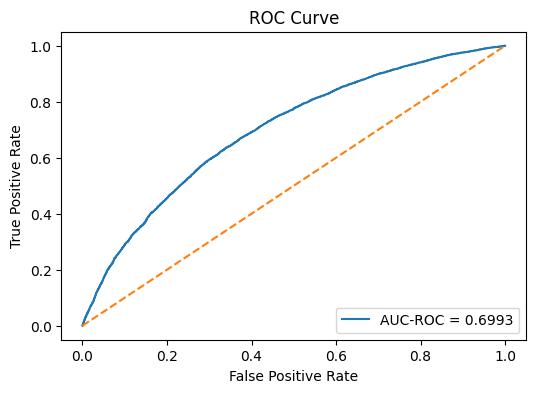

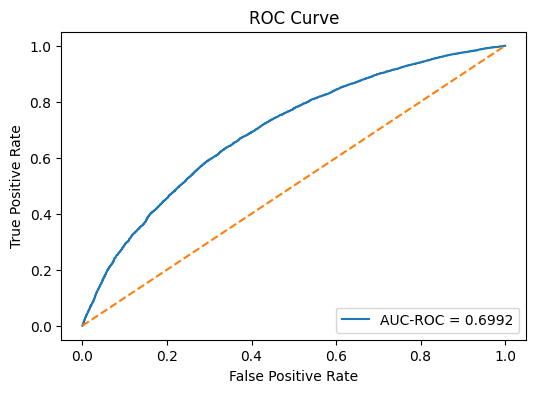

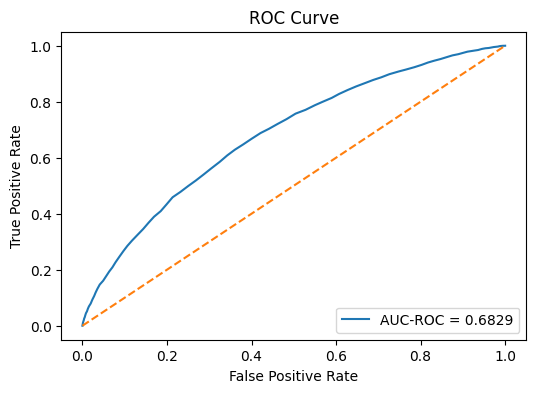

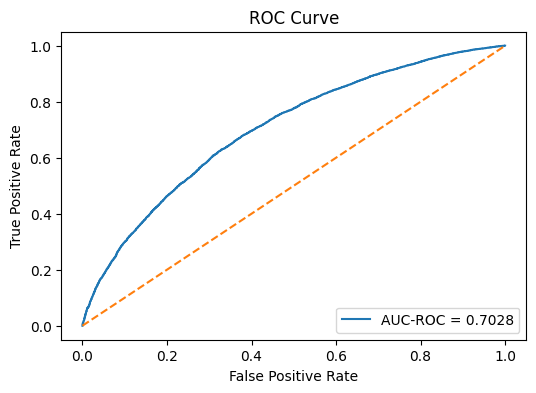

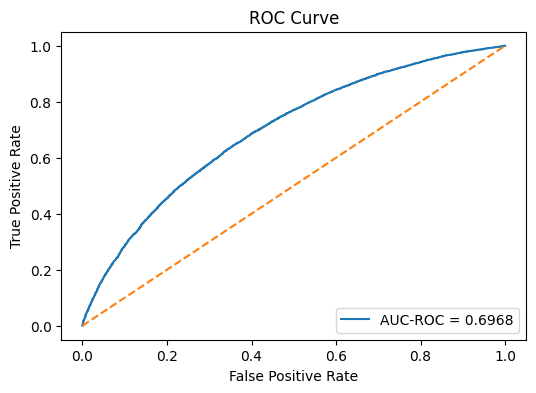

,Accuracy,F1 Score,AUC-ROC
L1 Logistic Regression,0.647723,0.659509,0.699264
L2 Logistic Regression,0.647819,0.659632,0.699232
Random Forest,0.633802,0.642262,0.682870
Gradient Boosting,0.649487,0.665727,0.702831
XGBoost,0.643147,0.657766,0.696815


In [6]:
results_L1 = evaluate_model(model_L1, X_test_transformed, y_test)
results_L2 = evaluate_model(model_L2, X_test_transformed, y_test)
results_RF = evaluate_model(model_RF, X_test_transformed, y_test)
results_GB = evaluate_model(model_GB, X_test_transformed, y_test)
results_XGB = evaluate_model(model_XGB, X_test_transformed, y_test)

results_df = pd.DataFrame({
    'L1 Logistic Regression': results_L1,
    'L2 Logistic Regression': results_L2,
    'Random Forest': results_RF,
    'Gradient Boosting': results_GB,
    'XGBoost': results_XGB
}).T

results_df

Among the evaluated models, Gradient Boosting achieved the strongest overall performance, with the highest Accuracy, F1-score, and AUC-ROC. This indicates that it provided the best balance of overall classification performance and discriminatory ability, and it was therefore selected as the final prepayment risk model for tuning.

### 6.6.3 Threshold Tuning<a id='6.6.3_Threshold_Tuning'></a>

After selecting Gradient Boosting as the best-performing model, threshold tuning was conducted to determine whether a classification threshold other than the default value of 0.5 could improve model performance.

In [7]:
y_prob_GB = model_GB.predict_proba(X_test_transformed)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
results = []

for threshold in thresholds:
    y_pred_thresh = (y_prob_GB >= threshold).astype(int)
    
    results.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred_thresh),
        'F1 Score': f1_score(y_test, y_pred_thresh)
    })

threshold_results = pd.DataFrame(results)
threshold_results

,Threshold,Accuracy,F1 Score
0,0.3,0.576973,0.693665
1,0.4,0.627080,0.696304
2,0.5,0.649487,0.665727
3,0.6,0.628892,0.559679
4,0.7,0.566627,0.322754
5,0.8,0.502646,0.048696


Threshold tuning was performed on the final Gradient Boosting model to identify the most suitable classification cutoff. Among the tested values, a threshold of 0.4 produced the highest F1-score while maintaining a reasonable level of Accuracy. Therefore, 0.4 was selected as the final threshold for the prepayment risk model.

### 6.6.4 Model Selection<a id='6.6.4_Model_Selection'></a>

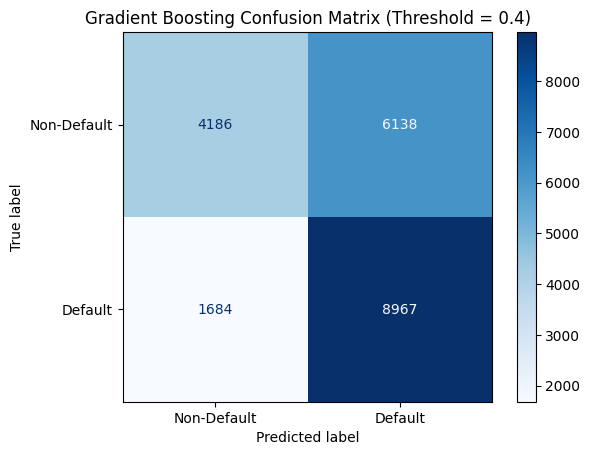

{'Accuracy': 0.6270798569725864,
 'F1 Score': 0.6963037738779314,
 'AUC-ROC': 0.7028312348484813}

In [8]:
# Predicted probabilities from Gradient Boosting
y_prob_GB = model_GB.predict_proba(X_test_transformed)[:, 1]

# Apply selected threshold
threshold = 0.4
y_pred_GB_04 = (y_prob_GB >= threshold).astype(int)

# Calculate metrics
results_GB_04 = {
    'Accuracy': accuracy_score(y_test, y_pred_GB_04),
    'F1 Score': f1_score(y_test, y_pred_GB_04),
    'AUC-ROC': roc_auc_score(y_test, y_prob_GB)
}

# Compute confusion matrix
cm_GB_04 = confusion_matrix(y_test, y_pred_GB_04)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_GB_04,
    display_labels=['Non-Default', 'Default']
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Gradient Boosting Confusion Matrix (Threshold = 0.4)')
plt.show()

results_GB_04

The final Gradient Boosting prepayment model, using a threshold of 0.4, achieved an Accuracy of 0.627, an F1-score of 0.696, and an AUC-ROC of 0.703. The confusion matrix shows that the model correctly identified 8,967 prepaid loans and 4,186 non-prepaid loans. This indicates that the model was relatively effective at identifying prepayment cases, although it also misclassified a considerable number of non-prepaid loans as prepaid. Overall, Gradient Boosting at a threshold of 0.4 was selected as the final prepayment risk model because it provided the best balance of classification performance among the tested candidates.

## 6.7 Summary<a id='6.7_Summary'></a>

This notebook developed and evaluated several classification models for mortgage prepayment risk prediction using the processed outputs from the feature engineering stage. Because the prepayment target was relatively balanced, no resampling step was applied, and model performance was assessed using **Accuracy, F1-score, and AUC-ROC**.

Among the evaluated models, **Gradient Boosting** achieved the strongest overall performance, producing the highest Accuracy, F1-score, and AUC-ROC. Threshold tuning was then conducted on the Gradient Boosting model to identify the most suitable classification cutoff. Based on this analysis, a threshold of **0.4** was selected because it produced the highest F1-score while maintaining a reasonable level of overall accuracy.

The final **Gradient Boosting** prepayment model, with a threshold of **0.4**, achieved an **Accuracy of 0.627**, an **F1-score of 0.696**, and an **AUC-ROC of 0.703**. The confusion matrix showed that the model correctly identified **8,967 prepaid loans** and **4,186 non-prepaid loans**, while also producing a notable number of false positive predictions. Overall, the final model demonstrated a reasonable ability to classify prepayment outcomes and provided the best balance of predictive performance among the tested candidates.

In [9]:
final_prepayment_model = {
    'model': model_GB,
    'transformer': transformer,
    'threshold': 0.4,
    'model_name': 'Gradient Boosting',
    'target_name': 'prepaid',
    'feature_names': X_train.columns.tolist(),
    'metrics': {
        'accuracy': 0.627,
        'f1_score': 0.696,
        'auc_roc': 0.703
    }
}

joblib.dump(final_prepayment_model, '../models/final_prepayment_model_pipeline.pkl')

print("Final prepayment model pipeline saved successfully.")

Final prepayment model pipeline saved successfully.
